# Olist End-to-End Business Data Analytics
## Notebook 02 — Exploratory Data Analysis & Business Analysis

The goal is to understand the main business patterns behind seller acquisition, marketplace performance and customer satisfaction before moving to SQL and final business recommendations.

## Main business questions

1. Which acquisition channels bring sellers with stronger commercial performance after conversion?
2. How reliable is delivery performance, and are there meaningful regional differences?
3. Which factors are most associated with lower customer satisfaction: delivery performance, product category, or price?
4. Do sellers acquired through different channels show different commercial performance, operational performance, and customer satisfaction?

## Analysis scope

The analysis focuses on three business areas:

- **Commercial performance:** GMV as the main metric, supported by number of orders and AOV.
- **Delivery performance:** average delivery time and late delivery rate.
- **Customer satisfaction:** average review score.

Each business question will use only the datasets, variables and metrics needed to answer it.

A key limitation is that only **380 of the 842 Marketing-acquired sellers** are observed in the available E-Commerce data. Therefore, analyses connecting acquisition channels with downstream seller performance apply only to this observable subset.

## Research hypotheses

### Q1 — Seller acquisition and commercial performance

**Research question:**  
Which acquisition channels bring sellers with stronger commercial performance after conversion?

**H0:** Mean GMV does not differ significantly across acquisition channels.

**H1:** Mean GMV differs significantly across acquisition channels.

**Primary metric:** GMV  
**Supporting metrics:** Number of orders and AOV


### Q2 — Marketplace delivery performance

**Research question:**  
How reliable is delivery performance, and are there meaningful regional differences?

**H0:** Mean delivery time does not differ significantly across regions.

**H1:** Mean delivery time differs significantly across regions.

**Primary metric:** Average delivery time  
**Supporting metric:** Late delivery rate

Delivery performance will be evaluated through average delivery time, late delivery rate and delivery-time variability.


### Q3 — Customer satisfaction

**Research question:**  
Which factors are most associated with lower customer satisfaction: delivery performance, product category or price?

**H0:** Delivery performance, product category and price are not significantly associated with review scores.

**H1:** At least one of these factors is significantly associated with review scores.

**Primary metric:** Average review score

In [1]:
# Import libraries 

import pandas as pd
import numpy as np

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Path to cleaned datasets exported from Notebook 1

PROCESSED_PATH = "../data/processed"

In [3]:
# Load cleaned E-Commerce datasets

customers = pd.read_csv(f"{PROCESSED_PATH}/customers_clean.csv")
orders = pd.read_csv(f"{PROCESSED_PATH}/orders_clean.csv")
order_items = pd.read_csv(f"{PROCESSED_PATH}/order_items_clean.csv")
payments = pd.read_csv(f"{PROCESSED_PATH}/payments_clean.csv")
reviews = pd.read_csv(f"{PROCESSED_PATH}/reviews_clean.csv")
products = pd.read_csv(f"{PROCESSED_PATH}/products_clean.csv")
sellers = pd.read_csv(f"{PROCESSED_PATH}/sellers_clean.csv")
geolocation = pd.read_csv(f"{PROCESSED_PATH}/geolocation_clean.csv")
category_translation = pd.read_csv(f"{PROCESSED_PATH}/category_translation_clean.csv")

In [4]:
# Load cleaned Marketing Funnel datasets

mql = pd.read_csv(f"{PROCESSED_PATH}/mql_clean.csv")
closed_deals = pd.read_csv(f"{PROCESSED_PATH}/closed_deals_clean.csv")

In [5]:
# Load ZIP-level geolocation reference created in Notebook 1

geolocation_zip = pd.read_csv(f"{PROCESSED_PATH}/geolocation_zip_reference.csv")

In [6]:
print("E-COMMERCE DATASETS")
print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("payments:", payments.shape)
print("reviews:", reviews.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("geolocation:", geolocation.shape) 
print("category_translation:", category_translation.shape) 

print("\nMARKETING FUNNEL DATASETS")
print("mql:", mql.shape)
print("closed_deals:", closed_deals.shape) 

print("\nZIP-level geolocation ")
print("geolocation_zip:", geolocation_zip.shape)

E-COMMERCE DATASETS
customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 5)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (738332, 5)
category_translation: (71, 2)

MARKETING FUNNEL DATASETS
mql: (8000, 4)
closed_deals: (842, 14)

ZIP-level geolocation 
geolocation_zip: (19015, 3)


### Data loaded

The cleaned datasets exported from Notebook 01 were loaded successfully.

The analysis will keep the E-Commerce and Marketing Funnel datasets separate until a specific business question requires connecting them. The ZIP-level geolocation reference will be used only when geographic coordinates are needed.

# 1. Prepare the analytical variables

## Business metrics dictionary

Before starting the EDA, the main business metrics used to answer the project questions are defined below.

The analysis focuses on three areas: **commercial performance, delivery performance, and customer satisfaction**.

| Area | Metric | Definition | Calculation |
|---|---|---|---|
| Commercial performance | **GMV** | Gross Merchandise Value. Total value of products sold by a seller in the marketplace. | Sum of `price` |
| Commercial performance | **Number of orders** | Number of unique orders in which a seller participated. | Unique count of `order_id` |
| Commercial performance | **AOV** | Average value generated by the seller per order. | GMV / Number of orders |
| Delivery performance | **Average delivery time** | Average number of days between purchase and delivery to the customer. | Delivery date - Purchase date |
| Delivery performance | **Late delivery rate** | Percentage of delivered orders that arrived after the estimated delivery date. | Late delivered orders / Delivered orders |
| Customer satisfaction | **Average review score** | Average customer review score associated with the seller's orders. | Mean `review_score` |

These metrics will be analyzed using the relevant business dimensions, such as **acquisition channel, customer region, product category, and price**, depending on the business question.

### 1.1. Build the seller commercial performance dataset

To answer the seller acquisition questions, we first create a seller-level dataset containing the commercial performance metrics needed for the analysis.

Each row represents one seller, with **GMV, number of orders and AOV** calculated from `order_items`.

This dataset will later be connected to the Marketing Funnel through `seller_id` to compare commercial performance across acquisition channels.

### Commercial performance

In [7]:
seller_commercial = order_items.groupby("seller_id").agg(gmv=("price", "sum"), number_of_orders=("order_id", "nunique")).reset_index() 
seller_commercial.head()

,seller_id,gmv,number_of_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200
2,001e6ad469a905060d959994f1b41e4f,250.00,1
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51
4,003554e2dce176b5555353e4f3555ac8,120.00,1


In [8]:
#AOV at the seller level: GMV / number of unique orders in which they participated.

seller_commercial["aov"] = seller_commercial["gmv"] / seller_commercial["number_of_orders"]
seller_commercial.head()

# Note: This is the value of what that seller sold within the order, not the total value of the customer's order (which may include other sellers).

,seller_id,gmv,number_of_orders,aov
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,895.000000
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,125.400150
2,001e6ad469a905060d959994f1b41e4f,250.00,1,250.000000
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,24.205882
4,003554e2dce176b5555353e4f3555ac8,120.00,1,120.000000


In [9]:
# Add acquisition channel to converted sellers

seller_acquisition = closed_deals[["seller_id", "mql_id"]].merge(mql[["mql_id", "origin"]],on="mql_id",how="left")

seller_acquisition.head()

,seller_id,mql_id,origin
0,2c43fb513632d29b3b58df74816f1b06,5420aad7fec3549a85876ba1c529bd84,organic_search
1,bbb7d7893a450660432ea6652310ebb7,a555fb36b9368110ede0f043dfc3b9a0,referral
2,612170e34b97004b3ba37eae81836b4c,327174d3648a2d047e8940d7d15204ca,organic_search
3,21e1781e36faf92725dde4730a88ca0f,f5fee8f7da74f4887f5bcae2bafb6dd6,paid_search
4,ed8cb7b190ceb6067227478e48cf8dde,ffe640179b554e295c167a2f6be528e0,unknown


## 2. Q1 — Seller acquisition and commercial performance

This section investigates whether sellers acquired through different Marketing Funnel channels show different commercial performance after conversion.

GMV is used as the primary commercial performance metric, while number of orders and AOV are used as supporting metrics.

The analysis first examines the acquisition-channel composition and overall GMV distribution before comparing seller performance across channels.

### 2.1 Build the Q1 analytical dataset

In [10]:
# Connect acquisition channel with seller commercial performance

seller_acquisition_performance = seller_acquisition.merge(seller_commercial, on="seller_id",how="inner")

seller_acquisition_performance.head()

,seller_id,mql_id,origin,gmv,number_of_orders,aov
0,2c43fb513632d29b3b58df74816f1b06,5420aad7fec3549a85876ba1c529bd84,organic_search,858.00,3,286.000000
1,612170e34b97004b3ba37eae81836b4c,327174d3648a2d047e8940d7d15204ca,organic_search,23065.02,107,215.560935
2,ed8cb7b190ceb6067227478e48cf8dde,ffe640179b554e295c167a2f6be528e0,unknown,573.50,15,38.233333
3,1c742ac33582852aaf3bcfbf5893abcf,b94fba7670eeb44dce2a0d8eb790e9f5,organic_search,97.90,1,97.900000
4,44ed138eca6214d572ce1d813fb0049b,b02c89251106e1fdd9d92744be9f94f2,unknown,129.79,2,64.895000


In [11]:
print("Sellers with acquisition and commercial performance:", seller_acquisition_performance["seller_id"].nunique())

print("Dataset shape:", seller_acquisition_performance.shape)

Sellers with acquisition and commercial performance: 380
Dataset shape: (380, 6)


### Analytical dataset check

The acquisition-performance dataset contains the Marketing-acquired sellers for whom commercial activity can be observed in the available E-Commerce data.

This matches the Marketing–E-Commerce overlap identified during the data validation performed in Notebook 01.

### 2.2 Acquisition channel distribution

In [12]:
seller_acquisition_performance["origin"].value_counts()

origin
organic_search    113
paid_search       101
unknown            81
direct_traffic     31
social             31
referral            9
email               6
missing             4
other               2
display             2
Name: count, dtype: int64

In [13]:
# Acquisition channel distribution (%)

seller_acquisition_performance["origin"].value_counts(normalize=True) * 100

origin
organic_search    29.736842
paid_search       26.578947
unknown           21.315789
direct_traffic     8.157895
social             8.157895
referral           2.368421
email              1.578947
missing            1.052632
other              0.526316
display            0.526316
Name: proportion, dtype: float64

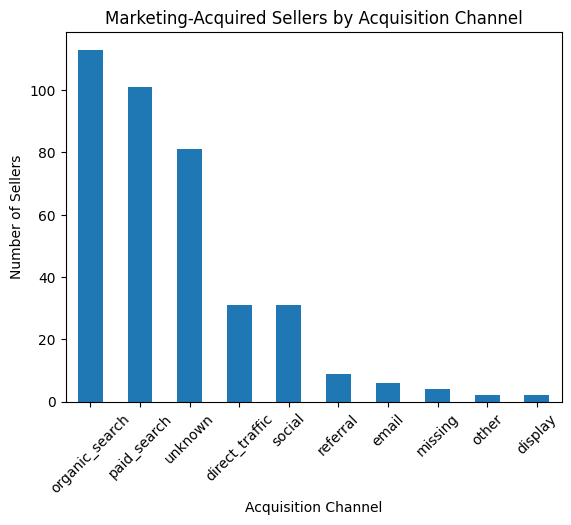

In [14]:
# Visualize acquisition channel distribution

seller_acquisition_performance["origin"].value_counts().plot(kind="bar")

plt.title("Marketing-Acquired Sellers by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Number of Sellers")
plt.xticks(rotation=45)
plt.show()

### Findings

The observable Marketing-acquired sellers are not evenly distributed across acquisition channels.

`organic_search` and `paid_search` are the two largest identifiable acquisition channels, while a relevant share of sellers has an `unknown` acquisition origin.

Several other acquisition channels contain substantially fewer observations. These differences in sample size should be considered when interpreting channel-level performance.

The `unknown` group will remain visible during the exploratory analysis, but it cannot be interpreted as a specific acquisition strategy.

### 2.3 GMV distribution

GMV is the primary metric used to measure seller commercial performance.

Before comparing acquisition channels, its overall distribution is examined to understand typical seller performance and determine whether extreme values may strongly influence the mean.

In [15]:
# Summary statistics for seller GMV

seller_acquisition_performance["gmv"].describe()

count       380.000000
mean       1781.188105
std        6800.937058
min          18.900000
25%         179.650000
50%         547.405000
75%        1286.000000
max      113628.970000
Name: gmv, dtype: float64

In [16]:
# Compare mean and median GMV

print("Mean GMV:", seller_acquisition_performance["gmv"].mean())

print("Median GMV:", seller_acquisition_performance["gmv"].median())

Mean GMV: 1781.188105263158
Median GMV: 547.405


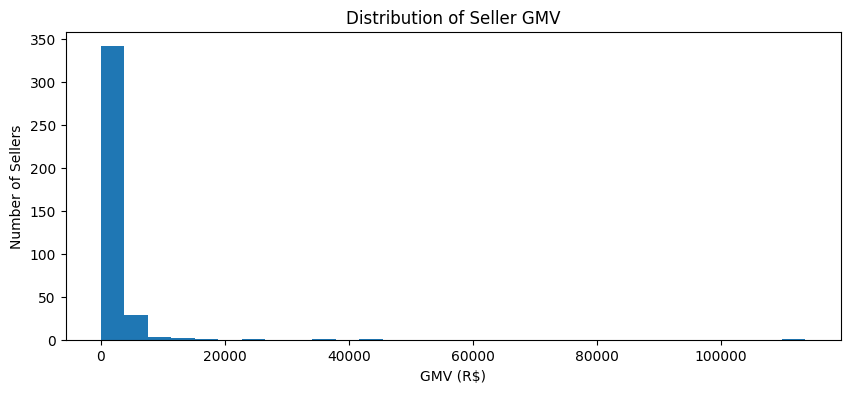

In [17]:
# Visualize GMV distribution

plt.figure(figsize=(10, 4))

plt.hist(seller_acquisition_performance["gmv"],bins=30)

plt.title("Distribution of Seller GMV")
plt.xlabel("GMV (R$)")
plt.ylabel("Number of Sellers")
plt.show()

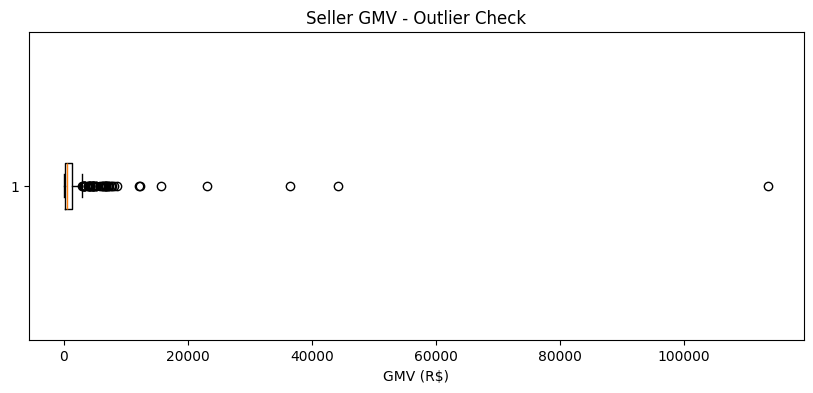

In [18]:
# Visualize GMV outliers

plt.figure(figsize=(10, 4))

plt.boxplot(seller_acquisition_performance["gmv"], vert=False)

plt.title("Seller GMV - Outlier Check")
plt.xlabel("GMV (R$)")
plt.show()

### 2.4 GMV outlier investigation

In [19]:
# Identify potential GMV outliers using IQR

Q1 = seller_acquisition_performance["gmv"].quantile(0.25)
Q3 = seller_acquisition_performance["gmv"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)

Q1: 179.65
Q3: 1286.0
IQR: 1106.35
Upper bound: 2945.5249999999996


In [20]:
# Inspect potential GMV outliers

gmv_outliers = seller_acquisition_performance[seller_acquisition_performance["gmv"] > upper_bound]

print("Number of potential outliers:", len(gmv_outliers))

gmv_outliers.sort_values("gmv", ascending=False).head(10)

Number of potential outliers: 46


,seller_id,mql_id,origin,gmv,number_of_orders,aov
12,7d13fca15225358621be4086e1eb0964,0b97be8b4b408a3a0780a32e0a143a7f,unknown,113628.97,565,201.113221
279,ba90964cff9b9e0e6f32b23b82465f7b,8257329475414b1eaf3dc731440e01a7,organic_search,44212.50,38,1163.486842
273,c70c1b0d8ca86052f45a432a38b73958,7b6ad2297d3beb569ddf3ee1ce22ffa8,paid_search,36537.37,261,139.989923
1,612170e34b97004b3ba37eae81836b4c,327174d3648a2d047e8940d7d15204ca,organic_search,23065.02,107,215.560935
36,6061155addc1e54b4cfb51c1c2a32ad8,8d6be534a8bdd08e11efe57c6ce3dd21,organic_search,15633.40,28,558.335714
316,c510bc1718f0f2961eaa42a23330681a,7bf1f5c2051159d32a588de7a73c8edf,unknown,12251.00,13,942.384615
14,70c27847eca8195c983ed7e798c56743,fc4166d1b1e192f650ee2d807b54c943,social,12077.52,77,156.850909
168,db2956745b3a8e9f3785c99f34b5d25e,e84d3444422cda735543114cf5df6b95,unknown,8599.00,47,182.957447
170,4bfc7a4a1cf8d4d2121c27422d9e50b5,860e39bc33e7c4ca4c26ec67979cc290,paid_search,8124.40,26,312.476923
363,8476243f92442881ddd5b578975cf115,1b9d7ffccca875a9079e3b57c24a3113,unknown,7838.00,12,653.166667


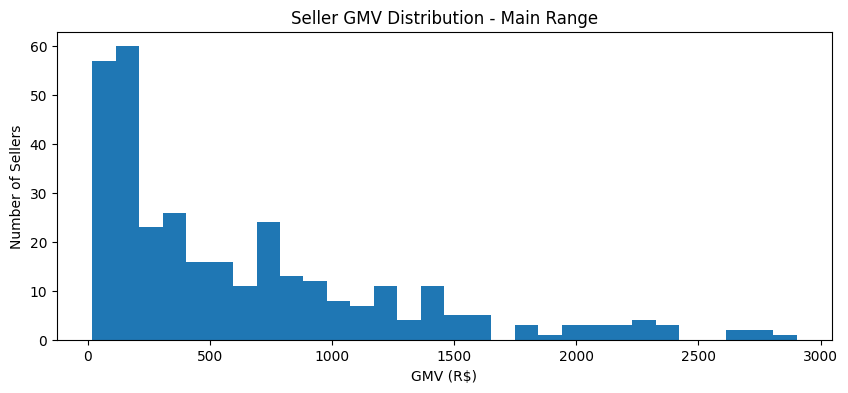

In [21]:
# Visualize the main GMV distribution below the IQR upper bound

gmv_main_distribution = seller_acquisition_performance[seller_acquisition_performance["gmv"] <= upper_bound]
plt.figure(figsize=(10, 4))
plt.hist(gmv_main_distribution["gmv"], bins=30)

plt.title("Seller GMV Distribution - Main Range")
plt.xlabel("GMV (R$)")
plt.ylabel("Number of Sellers")
plt.show()

#### GMV distribution findings

Seller GMV is strongly right-skewed. The mean GMV (1,781.19 BRL) is considerably higher than the median (547.41 BRL), indicating that a relatively small number of high-performing sellers are pulling the average upward.

Using the IQR method, 46 of the 380 sellers (12.1%) were identified as potential GMV outliers, with values above 2,945.52 BRL.

However, these observations are not automatically treated as errors. Several of the highest-GMV sellers also have a high number of orders, suggesting that at least part of these extreme values may represent genuinely high-performing sellers.

For this reason, potential GMV outliers are retained in the analysis. High GMV values may represent genuine high-performing sellers, and removing them could eliminate meaningful business information. Their influence on mean-based comparisons will therefore be considered when interpreting the results.

### 2.5 Commercial performance by acquisition channel

We now compare seller commercial performance across acquisition channels.

GMV remains the primary performance metric, while number of orders and AOV provide additional context.

Because GMV is strongly right-skewed and channel sample sizes vary considerably, both mean and median GMV are considered during the descriptive analysis.

In [22]:
# GMV performance by acquisition channel

gmv_by_channel = seller_acquisition_performance.groupby("origin")["gmv"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

gmv_by_channel

,count,mean,median
origin,,,
other,2,3444.325000,3444.325
referral,9,1987.461111,1368.500
social,31,1402.515806,722.200
organic_search,113,1832.065929,634.200
unknown,81,2638.798765,573.500
paid_search,101,1537.396535,512.000
display,2,461.500000,461.500
direct_traffic,31,706.577419,399.000
email,6,1414.165000,338.200


### 2.6 Focus on the two largest known acquisition channels

`organic_search` and `paid_search` are the two largest identifiable acquisition channels.

Because they provide the largest and most comparable samples, they are examined more closely to understand descriptive differences in seller commercial performance.

This comparison complements the broader channel-level analysis rather than replacing it.


In [23]:
# Two largest known acquisition channels

main_channels = seller_acquisition_performance[seller_acquisition_performance["origin"].isin(["organic_search", "paid_search"])]

main_channels.shape

(214, 6)

In [24]:
# GMV comparison between organic and paid search

main_channels.groupby("origin")["gmv"].agg(["count", "mean", "median"])

,count,mean,median
origin,,,
organic_search,113,1832.065929,634.2
paid_search,101,1537.396535,512.0


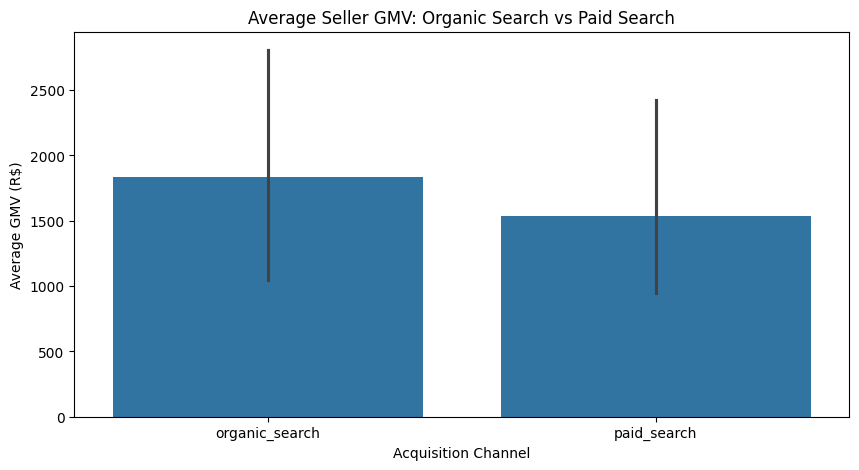

In [25]:
# Compare mean GMV between organic and paid search

plt.figure(figsize=(10, 5))

sns.barplot(data=main_channels, x="origin",y="gmv")

plt.title("Average Seller GMV: Organic Search vs Paid Search")
plt.xlabel("Acquisition Channel")
plt.ylabel("Average GMV (R$)")
plt.show()

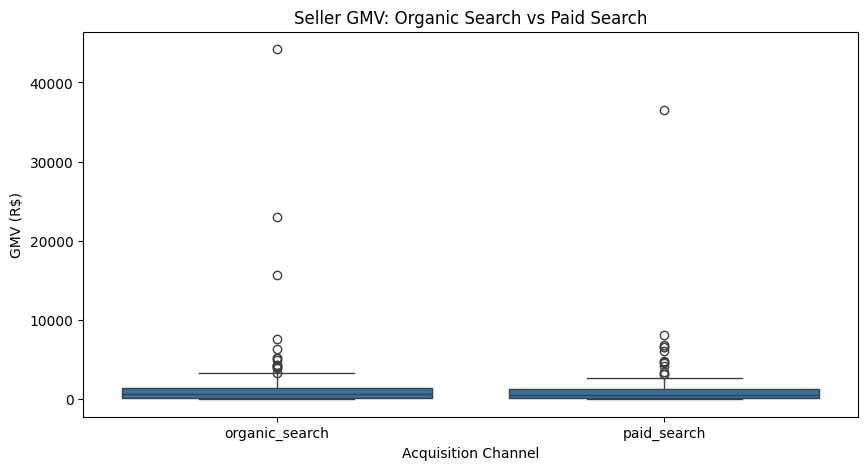

In [26]:
# Compare GMV distributions

plt.figure(figsize=(10, 5))

sns.boxplot(data=main_channels, x="origin",y="gmv")

plt.title("Seller GMV: Organic Search vs Paid Search")
plt.xlabel("Acquisition Channel")
plt.ylabel("GMV (R$)")
plt.show()

In [27]:
# Supporting commercial metrics

main_channels.groupby("origin")[["number_of_orders", "aov"]].agg(["mean", "median"])

number_of_orders                aov            
                           mean median        mean      median
origin                                                        
organic_search        10.690265    5.0  201.197235  105.533333
paid_search           12.346535    4.0  189.586840  104.750000

### Organic Search vs Paid Search — Initial findings

The descriptive comparison shows differences in GMV between the two largest known acquisition channels.

Number of orders and AOV provide additional context for understanding these differences rather than being treated as separate performance outcomes.

However, descriptive differences alone cannot determine whether acquisition channel is statistically associated with seller commercial performance.

Hypothesis testing is therefore used to evaluate whether the observed GMV differences are statistically significant.

### 2.7 Hypothesis testing — Acquisition channel and GMV

The exploratory analysis suggests differences in seller GMV across acquisition channels. Hypothesis testing will determine whether the observed differences among the main acquisition channels are statistically significant.

The formal comparison focuses on the four largest known acquisition channels with sufficient observations: `organic_search`, `paid_search`, `direct_traffic`, and `social`.

**H0:** Mean seller GMV is equal across the four main acquisition channels.

**H1:** At least one of the four main acquisition channels has a different mean seller GMV.

**Significance level:** α = 0.05

`unknown` and `missing` are excluded because they do not represent identifiable acquisition strategies. Smaller known channels remain visible in the exploratory analysis but are not included in the formal comparison because of their limited sample sizes.

In [28]:
# Main acquisition channels included in hypothesis testing

test_channels = seller_acquisition_performance[seller_acquisition_performance["origin"].isin(["organic_search", "paid_search", "direct_traffic", "social"])].copy()

test_channels["origin"].value_counts()


origin
organic_search    113
paid_search       101
direct_traffic     31
social             31
Name: count, dtype: int64

In [29]:
# GMV samples for hypothesis testing

organic_gmv = test_channels[test_channels["origin"] == "organic_search"]["gmv"]

paid_gmv = test_channels[test_channels["origin"] == "paid_search"]["gmv"]

direct_gmv = test_channels[test_channels["origin"] == "direct_traffic"]["gmv"]

social_gmv = test_channels[test_channels["origin"] == "social"]["gmv"]

print("Organic search:", len(organic_gmv))
print("Paid search:", len(paid_gmv))
print("Direct traffic:", len(direct_gmv))
print("Social:", len(social_gmv))

Organic search: 113
Paid search: 101
Direct traffic: 31
Social: 31


### 2.8 Normality check

Before running ANOVA, the GMV distribution is checked for the four channels included in the formal comparison.

In [30]:
# Import statistical functions for hypothesis testing
import scipy.stats as st

In [31]:
# Shapiro-Wilk normality test

for channel in test_channels["origin"].unique():

    channel_gmv = test_channels[
        test_channels["origin"] == channel]["gmv"]

    result = st.shapiro(channel_gmv)

    print(channel, "- n:", len(channel_gmv), "- p-value:", result.pvalue)

organic_search - n: 113 - p-value: 1.9869015966431024e-20
paid_search - n: 101 - p-value: 2.658258388265811e-19
direct_traffic - n: 31 - p-value: 5.0628908810178605e-09
social - n: 31 - p-value: 6.616837246664683e-09


### Normality check — interpretation

The Shapiro-Wilk test indicates that GMV is not normally distributed across the four acquisition channels included in the formal comparison (p < 0.05).

This result is consistent with the strong right-skew and extreme GMV values already observed during the exploratory analysis.

The normality assumption should therefore be considered when interpreting the ANOVA results.

### 2.9 ANOVA

In [32]:
# ANOVA across the four main acquisition channels

anova_stat, anova_p_value = st.f_oneway(organic_gmv, paid_gmv,direct_gmv,social_gmv)

print("ANOVA statistic:", anova_stat)
print("ANOVA p-value:", anova_p_value)

ANOVA statistic: 0.639429965873958
ANOVA p-value: 0.5902213226080906


In [33]:
# ANOVA decision

alpha = 0.05

if anova_p_value < alpha:
    print("The null hypothesis is rejected.")
else:
    print("The null hypothesis cannot be rejected.")

The null hypothesis cannot be rejected.


### 2.10 Hypothesis testing conclusion

The ANOVA p-value is greater than the 0.05 significance level, so we are not able to reject the null hypothesis.

Although the exploratory analysis showed descriptive differences in average and median GMV across acquisition channels, the formal comparison does not provide sufficient statistical evidence that mean seller GMV differs across the four main acquisition channels analyzed.

The ANOVA result should be interpreted with caution because the Shapiro-Wilk test showed that GMV is not normally distributed across these groups. The Kruskal-Wallis robustness check leads to the same overall conclusion.

### 2.11 Q1 — Business conclusion

The analysis does not identify a statistically significant difference in seller GMV across the four main acquisition channels.

Descriptively, `organic_search` shows stronger GMV performance than `paid_search`, while smaller channels also show some promising commercial results. However, these differences are not strong enough to conclude that acquisition channel alone explains seller commercial performance in the available data.

The supporting metrics also show that higher GMV is not explained by a single factor such as order volume or AOV.

From a business perspective, acquisition channel should therefore not be used alone as an indicator of future seller value. Other seller characteristics and downstream marketplace performance should be considered before prioritizing one acquisition channel over another.

# 3. Q2 — Marketplace delivery performance

## 3.1 Prepare the delivery performance dataset

To evaluate marketplace delivery performance, we first create an order-level dataset containing the information required to measure delivery speed and delivery reliability.

The analysis focuses on delivered orders, since actual delivery time can only be calculated when a customer delivery date is available.

Two main metrics will be created:

- **Delivery time:** number of days between purchase and actual customer delivery.
- **Late delivery:** whether the order was delivered after the estimated delivery date.

Customer location will later be added to evaluate regional differences in delivery performance.

In [34]:
# Keep delivered orders with the dates required for delivery analysis

delivery_orders = orders[(orders["order_status"] == "delivered") &(orders["order_delivered_customer_date"].notna())].copy()

delivery_orders.shape

(96470, 8)

In [35]:
# Check the relevant delivery dates

delivery_orders[["order_id", "customer_id", "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]].head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26


### 3.2 Create delivery performance metrics

Two operational metrics are calculated from the delivered orders:

- **Delivery time:** the number of days between the purchase timestamp and the actual customer delivery date.
- **Late delivery:** whether the order was delivered after the estimated delivery date.

These metrics will be used to evaluate overall delivery reliability and later compare performance across customer regions.

In [36]:
# Convert delivery date columns to datetime

delivery_orders["order_purchase_timestamp"] = pd.to_datetime(delivery_orders["order_purchase_timestamp"])

delivery_orders["order_delivered_customer_date"] = pd.to_datetime(delivery_orders["order_delivered_customer_date"])

delivery_orders["order_estimated_delivery_date"] = pd.to_datetime(delivery_orders["order_estimated_delivery_date"])

In [37]:
delivery_orders[["order_purchase_timestamp", "order_delivered_customer_date","order_estimated_delivery_date"]].dtypes

order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [38]:
# Calculate delivery time in days

delivery_orders["delivery_time_days"] = (delivery_orders["order_delivered_customer_date"] - delivery_orders["order_purchase_timestamp"]).dt.total_seconds() / (60 * 60 * 24)

delivery_orders[["order_id", "delivery_time_days"]].head()

,order_id,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877


In [39]:
# Flag late deliveries

delivery_orders["late_delivery"] = (delivery_orders["order_delivered_customer_date"] > delivery_orders["order_estimated_delivery_date"])

delivery_orders[["order_id", "order_delivered_customer_date","order_estimated_delivery_date","late_delivery"]].head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,False


In [40]:
# Check for impossible delivery times

print("Orders with negative delivery time:",(delivery_orders["delivery_time_days"] < 0).sum())

Orders with negative delivery time: 0


In [41]:
# Check late delivery distribution

delivery_orders["late_delivery"].value_counts()

late_delivery
False    88644
True      7826
Name: count, dtype: int64

### 3.3 Overall delivery performance 

Before comparing delivery performance across regions, we first examine the overall delivery performance of the marketplace.

The analysis focuses on two metrics:

- **Delivery time**, to understand how long customers typically wait to receive their orders.
- **Late delivery rate**, to evaluate how reliably orders are delivered within the estimated delivery date.

We first examine the distribution and summary statistics of delivery time before interpreting average performance.

In [42]:
# Summary statistics for delivery time

delivery_orders["delivery_time_days"].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_time_days, dtype: float64

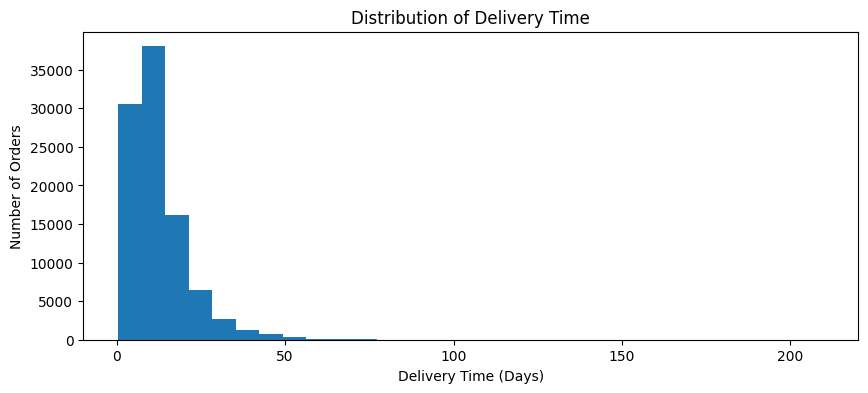

In [43]:
# Visualize delivery time distribution

plt.figure(figsize=(10, 4))

plt.hist(delivery_orders["delivery_time_days"], bins=30)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

In [44]:
# Calculate late delivery rate

late_delivery_rate = delivery_orders["late_delivery"].mean() * 100

print("Late delivery rate:", late_delivery_rate)

Late delivery rate: 8.112366538820359


In [45]:
# Inspect orders with the longest delivery times

delivery_orders[["order_id", "order_purchase_timestamp", "order_estimated_delivery_date","order_delivered_customer_date", "delivery_time_days", "late_delivery"]].sort_values("delivery_time_days", ascending=False).head(10)

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,delivery_time_days,late_delivery
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-03-22,2017-09-19 14:36:39,209.628611,True
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-03-15,2018-09-19 23:24:07,208.351759,True
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-04-07,2017-09-19 15:12:50,195.634016,True
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-04-17,2017-09-19 14:33:17,194.850174,True
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-04-06,2017-09-19 14:00:04,194.633611,True
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-04-11,2017-09-19 14:38:21,194.049583,True
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-01-19,2018-07-13 20:51:31,191.463542,True
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-04-05,2017-09-19 17:00:07,189.863160,True
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-04-13,2017-09-19 14:38:18,188.134618,True
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-04-10,2017-09-19 17:14:25,187.743843,True


In [46]:
# Investigate extreme delivery orders

extreme_delivery_orders = delivery_orders[delivery_orders["delivery_time_days"] > 180].copy()

extreme_delivery_orders.shape

(14, 10)

In [47]:
extreme_delivery_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,late_delivery
11399,47b40429ed8cce3aee9199792275433f,cb2caaaead400c97350c37a3fc536867,delivered,2018-01-03 09:44:01,2018-01-03 10:31:15,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,191.463542,True
19590,ca07593549f1816d26a572e06dc1eab6,75683a92331068e2d281b11a7866ba44,delivered,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,209.628611,True
31228,dfe5f68118c2576143240b8d78e5940a,8f6ceed676a529b29619a598b377de08,delivered,2017-03-17 12:32:22,2017-03-17 12:32:22,2017-03-21 18:28:04,2017-09-19 18:13:19,2017-04-19,186.236771,True
38509,0f4519c5f1c541ddec9f21b3bddd533a,1a8a4a30dc296976717f44e7801fdeef,delivered,2017-03-09 13:26:57,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,194.049583,True
54480,2d7561026d542c8dbd8f0daeadf67a43,8199345f57c6d1cbe9701f92481beb8d,delivered,2017-03-15 11:24:27,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13,188.134618,True


In [48]:
# Connect extreme delivery orders with sellers

extreme_delivery_sellers = extreme_delivery_orders.merge(order_items[["order_id", "seller_id"]], on="order_id",how="left")

extreme_delivery_sellers[["order_id", "seller_id", "delivery_time_days"]].head()

,order_id,seller_id,delivery_time_days
0,47b40429ed8cce3aee9199792275433f,cb41bfbcbda0aea354a834ab222f9a59,191.463542
1,ca07593549f1816d26a572e06dc1eab6,2a1348e9addc1af5aaa619b1a3679d6b,209.628611
2,dfe5f68118c2576143240b8d78e5940a,7c67e1448b00f6e969d365cea6b010ab,186.236771
3,0f4519c5f1c541ddec9f21b3bddd533a,7e93a43ef30c4f03f38b393420bc753a,194.049583
4,2d7561026d542c8dbd8f0daeadf67a43,e83c76265fc54bf41eac728805e4da77,188.134618


### Extreme delivery times

The longest delivery times reach approximately 180–210 days. These observations were inspected because they are substantially higher than the typical marketplace delivery time.

The corresponding orders can be traced to valid transactions and sellers, and their order timelines contain the relevant purchase and logistics timestamps.

Therefore, these extreme observations will be retained in the analysis. Although unusual, they may represent real cases of severe delivery delays and are relevant when evaluating marketplace delivery reliability.

Because the delivery-time distribution is right-skewed, both mean and median delivery time will be considered when interpreting performance.

### 3.4 Regional delivery performance

After evaluating overall marketplace delivery performance, the next step is to determine whether delivery speed and reliability vary across customer locations.

The analysis will compare delivery performance across Brazilian states using three main indicators:

- **Number of delivered orders:** to understand the sample size available for each state.
- **Delivery time:** to compare how long customers typically wait to receive their orders.
- **Late delivery rate:** to evaluate how reliably orders are delivered within the estimated delivery date.

Because delivery time is right-skewed and contains genuine extreme delays, both the mean and median will be considered when comparing states. The median will provide a more representative measure of typical delivery performance.

States with very small sample sizes will be interpreted cautiously, since their results may not represent stable regional patterns.

This exploratory analysis will identify whether regional differences appear to exist before hypothesis testing is used to determine whether those differences are statistically significant.

In [49]:
# Add customer state to delivery orders

delivery_regional = delivery_orders.merge(customers[["customer_id", "customer_state"]],on="customer_id",how="left")

delivery_regional[["order_id", "customer_id", "customer_state", "delivery_time_days", "late_delivery"]].head()

,order_id,customer_id,customer_state,delivery_time_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP,8.436574,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA,13.782037,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO,9.394213,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,RN,13.208750,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,SP,2.873877,False


In [50]:
# Check missing customer states

print("Missing customer states:",delivery_regional["customer_state"].isna().sum())

Missing customer states: 0


In [51]:
# Number of delivered orders by customer state

orders_by_state = delivery_regional["customer_state"].value_counts()

orders_by_state

customer_state
SP    40494
RJ    12350
MG    11354
RS     5344
PR     4923
SC     3546
BA     3256
DF     2080
ES     1995
GO     1957
PE     1593
CE     1279
PA      946
MT      886
MA      717
MS      701
PB      517
PI      476
RN      474
AL      397
SE      335
TO      274
RO      243
AM      145
AC       80
AP       67
RR       41
Name: count, dtype: int64

In [52]:
# Delivery performance by customer state

delivery_by_state = (delivery_regional.groupby("customer_state").agg(number_of_orders=("order_id", "nunique"), mean_delivery_time=("delivery_time_days", "mean"), median_delivery_time=("delivery_time_days", "median"), late_delivery_rate=("late_delivery", "mean")).reset_index())

delivery_by_state["late_delivery_rate"] = (delivery_by_state["late_delivery_rate"] * 100)

delivery_by_state.head()

,customer_state,number_of_orders,mean_delivery_time,median_delivery_time,late_delivery_rate
0,AC,80,21.035713,18.356528,3.750000
1,AL,397,24.543855,22.332917,23.929471
2,AM,145,26.425991,25.875139,4.137931
3,AP,67,27.185068,24.347025,4.477612
4,BA,3256,19.335466,16.913964,14.035627


In [53]:
# Summary of order volume across states

delivery_by_state["number_of_orders"].describe()

count       27.000000
mean      3572.962963
std       8020.735850
min         41.000000
25%        366.000000
50%        886.000000
75%       2668.000000
max      40494.000000
Name: number_of_orders, dtype: float64

In [54]:
# States ordered by number of delivered orders

delivery_by_state.sort_values("number_of_orders",ascending=False)

,customer_state,number_of_orders,mean_delivery_time,median_delivery_time,late_delivery_rate
25,SP,40494,8.761386,7.210272,5.894700
18,RJ,12350,15.309438,12.041644,13.473684
10,MG,11354,12.008666,10.313513,5.610358
22,RS,5344,15.300276,13.177488,7.148204
17,PR,4923,11.991582,10.425509,4.996953
23,SC,3546,14.954783,13.014352,9.757473
4,BA,3256,19.335466,16.913964,14.035627
6,DF,2080,12.967568,11.364925,7.067308
7,ES,1995,15.789307,13.636956,12.230576
8,GO,1957,15.606339,13.949606,8.175779


In [55]:
# States with the longest typical delivery times

delivery_by_state.sort_values("median_delivery_time",ascending=False)[["customer_state", "number_of_orders", "mean_delivery_time", "median_delivery_time"]]

,customer_state,number_of_orders,mean_delivery_time,median_delivery_time
2,AM,145,26.425991,25.875139
21,RR,41,29.387546,25.007303
3,AP,67,27.185068,24.347025
1,AL,397,24.543855,22.332917
13,PA,946,23.772917,21.078391
9,MA,717,21.572976,19.190602
0,AC,80,21.035713,18.356528
5,CE,1279,21.266579,18.209201
14,PB,517,20.426768,18.152442
24,SE,335,21.519788,18.014306


In [56]:
# States with the lowest late delivery rates

delivery_by_state.sort_values("late_delivery_rate")[["customer_state", "number_of_orders", "late_delivery_rate"]]

,customer_state,number_of_orders,late_delivery_rate
20,RO,243,2.880658
0,AC,80,3.750000
2,AM,145,4.137931
3,AP,67,4.477612
17,PR,4923,4.996953
10,MG,11354,5.610358
25,SP,40494,5.894700
12,MT,886,6.772009
6,DF,2080,7.067308
22,RS,5344,7.148204


In [57]:
# States with the highest late delivery rates

delivery_by_state.sort_values("late_delivery_rate",ascending=False)[["customer_state", "number_of_orders", "late_delivery_rate"]]

,customer_state,number_of_orders,late_delivery_rate
1,AL,397,23.929471
9,MA,717,19.665272
16,PI,476,15.966387
5,CE,1279,15.324472
24,SE,335,15.223881
4,BA,3256,14.035627
18,RJ,12350,13.473684
26,TO,274,12.773723
13,PA,946,12.367865
7,ES,1995,12.230576


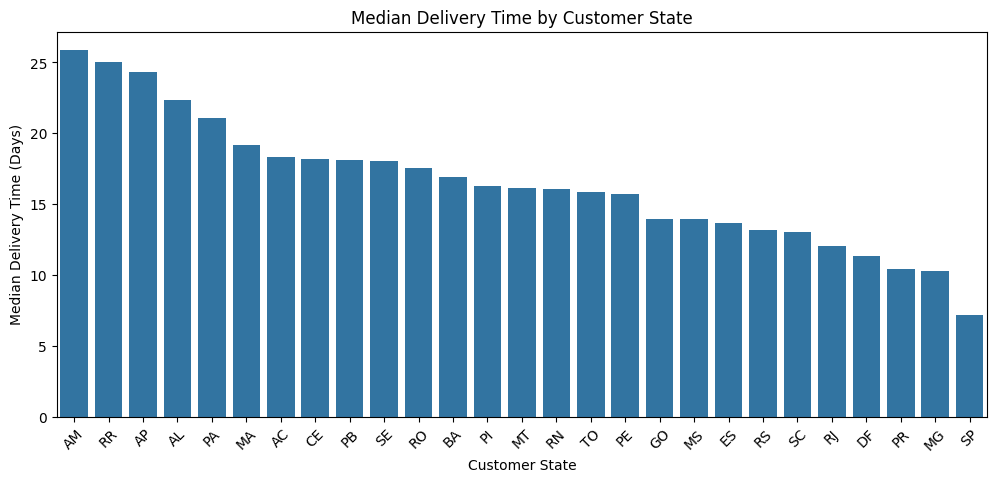

In [58]:
# Visualize median delivery time by customer state

state_order = (delivery_by_state.sort_values("median_delivery_time", ascending=False)["customer_state"])

plt.figure(figsize=(12, 5))

sns.barplot(data=delivery_by_state, x="customer_state", y="median_delivery_time", order=state_order)

plt.title("Median Delivery Time by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Median Delivery Time (Days)")
plt.xticks(rotation=45)

plt.show()

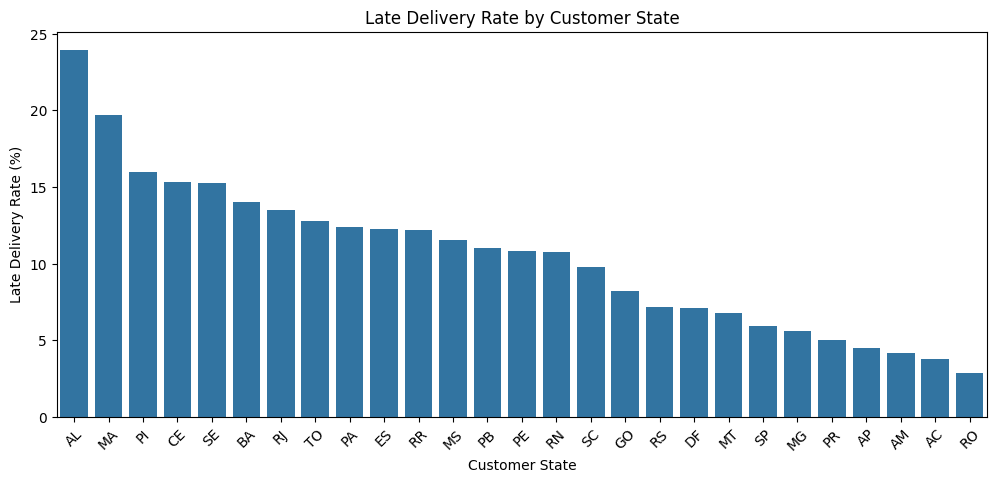

In [59]:
# Visualize late delivery rate by customer state

state_order_late = (delivery_by_state.sort_values("late_delivery_rate", ascending=False)["customer_state"])

plt.figure(figsize=(12, 5))

sns.barplot(data=delivery_by_state, x="customer_state", y="late_delivery_rate", order=state_order_late)

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)

plt.show()

### Regional delivery performance — Findings

Delivery performance varies substantially across Brazilian states, both in terms of delivery speed and delivery reliability.

Median delivery time shows a clear regional variation. São Paulo (SP), which represents the largest order volume in the dataset, has one of the shortest typical delivery times at approximately 7.2 days. In contrast, states such as Amazonas (AM), Roraima (RR), and Amapá (AP) show median delivery times of approximately 24–26 days.

However, longer delivery times do not necessarily correspond to higher late delivery rates. For example, AM has one of the longest median delivery times (approximately 25.9 days) but a relatively low late delivery rate of 4.1%. This suggests that longer expected delivery windows may already be incorporated into the estimated delivery dates for some regions.

In contrast, Alagoas (AL) combines a relatively long median delivery time (approximately 22.3 days) with the highest late delivery rate in the dataset (23.9%). Other states with substantial order volumes, including Bahia (BA), Rio de Janeiro (RJ), and Ceará (CE), also show late delivery rates above the marketplace average.

Overall, the results indicate that **delivery speed and delivery reliability represent two different dimensions of operational performance**. Geographic location appears to be an important operational factor, but slower delivery does not automatically imply less reliable delivery.

These findings suggest that regional performance should be evaluated using both actual delivery time and the ability to meet the promised delivery date.

### 3.5 Hypothesis testing — Regional delivery time

The exploratory analysis shows substantial differences in delivery time across Brazilian states. Hypothesis testing is used to determine whether these observed regional differences are statistically significant.

**H0:** Mean delivery time does not differ significantly across customer states.

**H1:** Mean delivery time differs significantly across customer states.

**Significance level:** α = 0.05

Because delivery time is strongly right-skewed and contains genuine extreme values, ANOVA will be reported as a comparison of mean delivery time.

In [60]:
# Create delivery time groups by customer state

state_groups = [group["delivery_time_days"].dropna()for state, group in delivery_regional.groupby("customer_state")]

print("Number of states:", len(state_groups))

Number of states: 27


In [61]:
# ANOVA across customer states

anova_stat, anova_p_value = st.f_oneway(*state_groups)

print("ANOVA statistic:", anova_stat)
print("ANOVA p-value:", anova_p_value)

ANOVA statistic: 783.1760850161149
ANOVA p-value: 0.0


In [62]:
# ANOVA decision

alpha = 0.05

if anova_p_value < alpha:
    print("The null hypothesis is rejected.")
else:
    print("The null hypothesis cannot be rejected.")

The null hypothesis is rejected.


### Hypothesis testing conclusion

The ANOVA p-value is below the significance level of 0.05. Therefore, the null hypothesis is rejected.

The results provide strong statistical evidence that mean delivery time differs across Brazilian states. This supports the regional differences observed during the exploratory analysis.

### Business conclusion

Delivery performance shows significant regional differences across Brazil. Delivery times vary substantially between states, while delivery reliability does not always follow the same pattern: regions with longer delivery times are not necessarily more likely to deliver late.

This suggests that delivery speed and delivery reliability should be evaluated separately when identifying regional operational issues.

# 4. Q3 — Customer satisfaction

### Research question

**Which factors are most associated with lower customer satisfaction: delivery performance, product category or price?**

Customer satisfaction is measured using the customer review score, which ranges from 1 to 5.

The analysis evaluates three potential factors:

- **Delivery performance:** whether longer delivery times or late deliveries are associated with lower review scores.
- **Product category:** whether customer satisfaction varies across product categories.
- **Price:** whether higher or lower order values are associated with different review scores.

### Hypotheses

**H0:** Delivery performance, product category and price are not significantly associated with review scores.

**H1:** At least one of these factors is significantly associated with review scores.

**Primary metric:** Average review score

## 4.1 Prepare the customer satisfaction dataset

Customer reviews are recorded at the review level, while the analyses in this research question primarily use the order as the unit of analysis.

The review data is therefore inspected before connecting customer satisfaction with delivery performance, product category and price.

Some orders contain multiple review records. To ensure that each order contributes only one satisfaction observation, review scores are aggregated by `order_id` using the mean.

For orders with identical review scores, the resulting value remains unchanged. For orders with different review scores, the mean represents the overall satisfaction score associated with that order.

In [63]:
# Inspect customer review data

reviews[["review_id", "order_id", "review_score"]].head()

,review_id,order_id,review_score
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5


In [64]:
# Check review score availability

print("Number of reviews:", len(reviews))
print("Missing review scores:", reviews["review_score"].isna().sum())

Number of reviews: 99224
Missing review scores: 0


In [65]:
# Distribution
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [66]:
# Inspect orders with multiple review records

duplicate_review_orders = reviews[reviews["order_id"].duplicated(keep=False)]

print("Orders with multiple review records:", duplicate_review_orders["order_id"].nunique())

Orders with multiple review records: 547


In [67]:
# Check review score consistency for orders with multiple reviews

review_scores_per_order = (duplicate_review_orders.groupby("order_id")["review_score"].nunique())

review_scores_per_order.value_counts().sort_index()

review_score
1    345
2    202
Name: count, dtype: int64

Among the 547 orders with multiple review records, 345 contain the same review score across records, while 202 contain different scores.

To maintain the order as the unit of analysis and avoid giving additional weight to orders with multiple reviews, one satisfaction score is created per order using the mean review score.

In [68]:
# Create one satisfaction score per order

reviews_order_level = (reviews.groupby("order_id")["review_score"].mean().reset_index())

reviews_order_level.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [69]:
# Validate order-level reviews

print("Dataset shape:", reviews_order_level.shape)
print("Unique orders:", reviews_order_level["order_id"].nunique())
print("Duplicated order IDs:", reviews_order_level["order_id"].duplicated().sum())
print("Missing review scores:", reviews_order_level["review_score"].isna().sum())

Dataset shape: (98673, 2)
Unique orders: 98673
Duplicated order IDs: 0
Missing review scores: 0


## 4.2 Delivery performance and customer satisfaction

The first factor evaluated is delivery performance.

Two dimensions are considered:

- **Delivery time:** the number of days between purchase and delivery.
- **Delivery reliability:** whether the order was delivered after the estimated delivery date.

These metrics are compared with customer review scores to evaluate whether poorer delivery performance is associated with lower customer satisfaction.

### 4.2.1 Connect delivery performance with satisfaction

In [70]:
satisfaction_orders = reviews_order_level.merge(delivery_orders[["order_id", "delivery_time_days", "late_delivery"]],on="order_id",how="inner")

satisfaction_orders.head()

,order_id,review_score,delivery_time_days,late_delivery
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,7.614421,False
1,00018f77f2f0320c557190d7a144bdd3,4.0,16.216181,False
2,000229ec398224ef6ca0657da4fc703e,5.0,7.948437,False
3,00024acbcdf0a6daa1e931b038114c75,4.0,6.147269,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,25.114352,False


In [71]:
# Validate delivery and satisfaction dataset

print("Dataset shape:", satisfaction_orders.shape)
print("Unique orders:", satisfaction_orders["order_id"].nunique())
print("Duplicated order IDs:", satisfaction_orders["order_id"].duplicated().sum())
print(satisfaction_orders.isna().sum())

Dataset shape: (95824, 4)
Unique orders: 95824
Duplicated order IDs: 0
order_id              0
review_score          0
delivery_time_days    0
late_delivery         0
dtype: int64


### 4.2.2 Delivery time by review score

In [72]:
# Keep original review scores for descriptive comparison

delivery_review_original = satisfaction_orders[satisfaction_orders["review_score"].isin([1, 2, 3, 4, 5])].copy()

delivery_by_review = (delivery_review_original.groupby("review_score")["delivery_time_days"].agg(["count", "mean", "median"]).reset_index())

delivery_by_review

,review_score,count,mean,median
0,1.0,9312,21.340088,16.807986
1,2.0,2916,16.663602,13.274734
2,3.0,7915,14.244110,12.039896
3,4.0,18868,12.306680,10.786562
4,5.0,56697,10.678551,9.230104


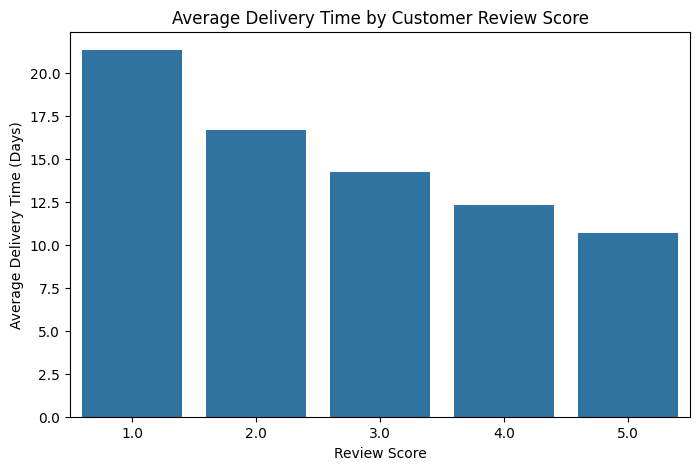

In [73]:
# Average delivery time by review score

plt.figure(figsize=(8, 5))

sns.barplot(data=delivery_by_review,x="review_score",y="mean")

plt.title("Average Delivery Time by Customer Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")
plt.show()

In [74]:
# Late delivery rate by review score

late_rate_by_review = (delivery_review_original.groupby("review_score")["late_delivery"].mean().mul(100).reset_index(name="late_delivery_rate"))

late_rate_by_review

,review_score,late_delivery_rate
0,1.0,37.940292
1,2.0,20.644719
2,3.0,10.966519
3,4.0,5.008480
4,5.0,3.000159


### 4.2.3 Late delivery rate by review score

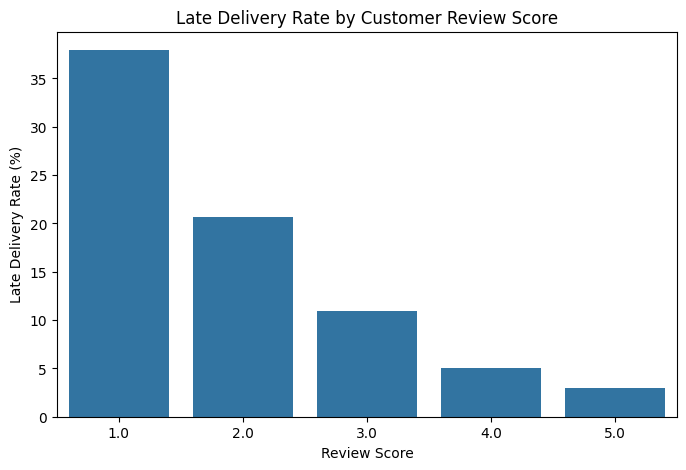

In [75]:
# Late delivery rate by review score

plt.figure(figsize=(8, 5))

sns.barplot(data=late_rate_by_review, x="review_score", y="late_delivery_rate")

plt.title("Late Delivery Rate by Customer Review Score")
plt.xlabel("Review Score")
plt.ylabel("Late Delivery Rate (%)")
plt.show()

### Delivery performance findings

Delivery performance shows a clear relationship with customer satisfaction.

Average delivery time decreases consistently as review scores improve. Orders receiving 1-star reviews take approximately 21 days to arrive on average, compared with approximately 11 days for 5-star reviews.

Delivery reliability shows an even clearer pattern. Approximately 37.8% of 1-star reviews are associated with late deliveries, compared with only around 3.0% of 5-star reviews.

The descriptive evidence therefore suggests that longer and late deliveries are strongly associated with lower customer satisfaction.

## 4.3 Product category and customer satisfaction

The second factor evaluated is product category.

Product category information is recorded at the order-item level, while customer satisfaction is measured at the order level.

To avoid duplicating customer satisfaction observations, the analysis retains orders associated with a single product category. Multiple items belonging to the same category can therefore remain part of the same order without duplicating its review score.

### 4.3.1 Prepare product categories

Product category information is connected with order items using `product_id`.

Olist provides a separate translation table containing the Portuguese product category names and their English equivalents. This lookup table is merged using `product_category_name`.

Categories not included in the translation table are completed manually so that all available orders can remain in the analysis.

In [76]:
# Connect order items with product categories

order_product_categories = (order_items[["order_id", "product_id"]].merge(products[["product_id", "product_category_name"]], on="product_id", how="left"))

order_product_categories.head()

,order_id,product_id,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim


In [77]:
# Add English product category names using Olist translation table

order_product_categories = order_product_categories.merge(category_translation, on="product_category_name", how="left")

order_product_categories[["order_id", "product_id", "product_category_name", "product_category_name_english"]].head()

,order_id,product_id,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,garden_tools


In [78]:
# Check categories without English translation

missing_translations = (order_product_categories[order_product_categories["product_category_name_english"].isna()]["product_category_name"].value_counts())

missing_translations

product_category_name
unknown                                          1603
portateis_cozinha_e_preparadores_de_alimentos      15
pc_gamer                                            9
Name: count, dtype: int64

In [79]:
# Complete categories not included in Olist translation table

missing_category_translation = {"unknown": "unknown", "portateis_cozinha_e_preparadores_de_alimentos": "small_kitchen_appliances", "pc_gamer": "pc_gamer"}

order_product_categories["product_category_name_english"] = (order_product_categories["product_category_name_english"].fillna(order_product_categories["product_category_name"].map(missing_category_translation)))

In [80]:
# Validate English category names

print("Missing English categories:", order_product_categories["product_category_name_english"].isna().sum())
print("Unique English categories:",order_product_categories["product_category_name_english"].nunique())

Missing English categories: 0
Unique English categories: 74


### 4.3.2 Identify single-category orders

In [81]:
# Count unique product categories per order

categories_per_order = (order_product_categories.groupby("order_id")["product_category_name_english"].nunique())

categories_per_order.value_counts().sort_index()

product_category_name_english
1    97880
2      768
3       18
Name: count, dtype: int64

In [82]:
# Keep orders associated with exactly one product category

single_category_orders = categories_per_order[categories_per_order == 1].index

order_category = (order_product_categories[order_product_categories["order_id"].isin(single_category_orders)][["order_id", "product_category_name_english"]].drop_duplicates())

print("Orders included:", len(order_category))
print("Duplicated order IDs:", order_category["order_id"].duplicated().sum())

Orders included: 97880
Duplicated order IDs: 0


### 4.3.3 Create one category per order

In [83]:
# Connect product category with customer satisfaction

category_satisfaction = order_category.merge(reviews_order_level, on="order_id", how="inner")

print("Orders included:", len(category_satisfaction))
print("Duplicated order IDs:",category_satisfaction["order_id"].duplicated().sum())

Orders included: 97137
Duplicated order IDs: 0


### 4.3.4 Negative satisfaction by product category

In [84]:
# Create negative review indicator

category_satisfaction["negative_review"] = (category_satisfaction["review_score"] <= 2)

In [85]:
# Calculate customer satisfaction metrics by category

category_results = (category_satisfaction.groupby("product_category_name_english").agg(number_of_orders=("order_id", "count"), mean_review_score=("review_score", "mean"),negative_review_rate=("negative_review", "mean")).reset_index())

category_results["negative_review_rate"] *= 100

In [86]:
# Keep categories with sufficient sample size

problem_categories = (category_results[category_results["number_of_orders"] >= 100].sort_values("negative_review_rate", ascending=False))

problem_categories.head()

,product_category_name_english,number_of_orders,mean_review_score,negative_review_rate
30,fashion_male_clothing,110,3.727273,25.454545
57,office_furniture,1248,3.631811,22.275641
4,audio,341,3.846041,21.407625
19,construction_tools_safety,159,3.874214,19.496855
34,fixed_telephony,212,3.891509,18.867925


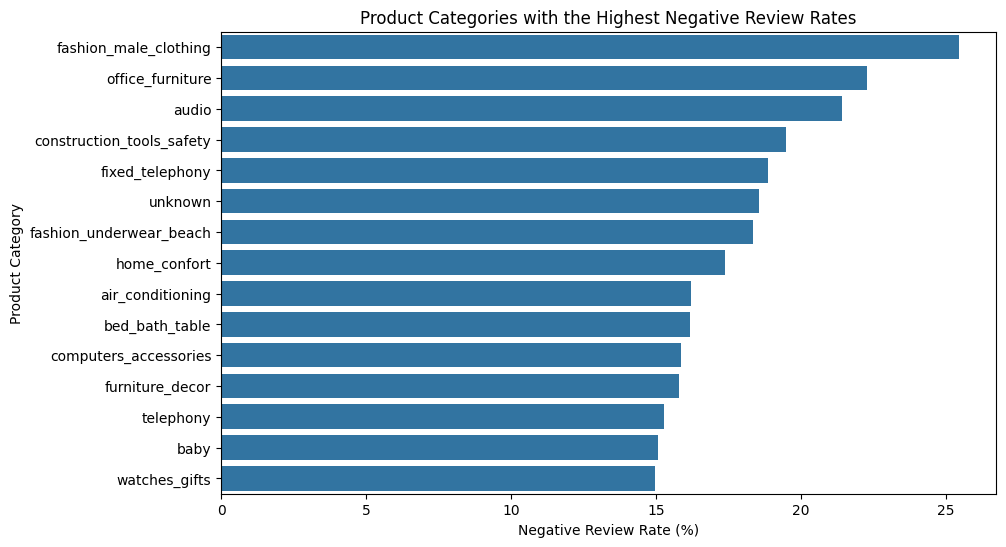

In [87]:
# Categories with the highest negative review rates

top_negative_categories = problem_categories.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(data=top_negative_categories,y="product_category_name_english", x="negative_review_rate")

plt.title("Product Categories with the Highest Negative Review Rates")
plt.xlabel("Negative Review Rate (%)")
plt.ylabel("Product Category")
plt.show()

### Product category findings

Customer dissatisfaction is not evenly distributed across product categories.

Among categories with at least 100 reviewed orders, some categories show substantially higher proportions of 1- and 2-star reviews than others.

`fashion_male_clothing`, `office_furniture`, `audio` and `construction_tools_safety` show some of the highest negative review rates among the categories with sufficient sample sizes.

This suggests that product category may be associated with customer satisfaction and that specific categories should be investigated further to identify potential product, seller or fulfillment issues.

## 4.4 Price and customer satisfaction

The final factor evaluated is order price.

Price information is recorded at the order-item level. Therefore, item prices are aggregated by `order_id` to create the total product value of each order before connecting price with customer satisfaction.

The analysis evaluates whether order value shows a meaningful relationship with customer review scores.

#### 4.4.1 Prepare order price

In [88]:
# Create total product price per order

order_price = (order_items.groupby("order_id")["price"].sum().reset_index(name="order_price"))

order_price.head()

,order_id,order_price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [89]:
# Connect order price with customer satisfaction

price_satisfaction = order_price.merge(reviews_order_level, on="order_id", how="inner")

print("Orders included:", len(price_satisfaction))
print("Duplicated order IDs:", price_satisfaction["order_id"].duplicated().sum())

Orders included: 97917
Duplicated order IDs: 0


#### 4.4.2 Price by review score

In [90]:
# Keep original review scores for descriptive comparison

price_review_original = price_satisfaction[price_satisfaction["review_score"].isin([1, 2, 3, 4, 5])].copy()

price_by_review = (price_review_original.groupby("review_score")["order_price"].agg(["count", "mean", "median"]).reset_index())

price_by_review

,review_score,count,mean,median
0,1.0,10778,166.972587,99.00
1,2.0,3063,145.613647,89.90
2,3.0,8083,127.637940,82.99
3,4.0,18986,132.482081,84.00
4,5.0,56885,134.674662,84.99


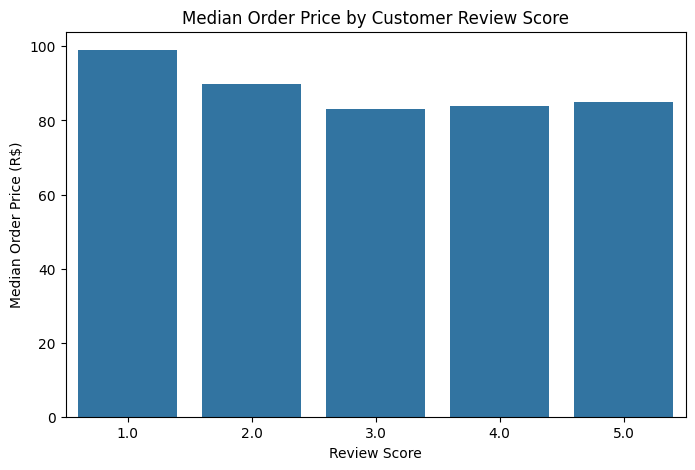

In [91]:
# Median order price by review score

plt.figure(figsize=(8, 5))

sns.barplot(data=price_by_review, x="review_score", y="median")

plt.title("Median Order Price by Customer Review Score")
plt.xlabel("Review Score")
plt.ylabel("Median Order Price (R$)")
plt.show()

### Price findings

Order price shows a considerably weaker descriptive relationship with customer satisfaction than delivery performance.

Orders receiving 1-star reviews have the highest median order value, at approximately 99 BRL, compared with approximately 83 BRL–85 BRL for orders receiving 3- to 5-star reviews.

However, the differences are relatively small and there is no clear progressive relationship between order price and review score.

The descriptive evidence therefore suggests that price alone is unlikely to be a major driver of customer dissatisfaction.

## 4.5 Hypothesis testing

The exploratory analysis identified different patterns between customer satisfaction and delivery performance, product category and order price.

Statistical tests are now used to determine whether these observed differences are statistically significant.

**H0:** Delivery performance, product category and price are not significantly associated with review scores.

**H1:** At least one of these factors is significantly associated with review scores.

A significance level of **α = 0.05** is used.

Because the three factors have different structures, each relationship is tested separately. The combined evidence is then used to evaluate the overall research hypothesis.

### 4.5.1 Delivery performance

To test whether delivery reliability is associated with customer satisfaction, average review scores are compared between on-time and late deliveries.

**H0:** On-time and late deliveries have the same mean review score.

**H1:** On-time and late deliveries have different mean review scores.

In [92]:
# Create review score groups by delivery reliability

on_time_reviews = satisfaction_orders[satisfaction_orders["late_delivery"] == False]["review_score"].dropna()

late_reviews = satisfaction_orders[satisfaction_orders["late_delivery"] == True]["review_score"].dropna()

print("On-time orders:", len(on_time_reviews))
print("Late orders:", len(late_reviews))

print("Mean review score - On time:", on_time_reviews.mean())
print("Mean review score - Late:", late_reviews.mean())

On-time orders: 88163
Late orders: 7661
Mean review score - On time: 4.294292012144172
Mean review score - Late: 2.566505678109907


In [93]:
# Independent t-test: on-time vs late deliveries

delivery_t_stat, delivery_p_value = st.ttest_ind(on_time_reviews, late_reviews, equal_var=False)

print("T-statistic:", delivery_t_stat)
print("P-value:", delivery_p_value)

T-statistic: 89.38438975067758
P-value: 0.0


### 4.5.2 Product category

ANOVA is used to test whether mean customer review scores differ across product categories.

Only categories with at least 100 reviewed orders are included to reduce the influence of very small sample sizes.

**H0:** Mean review score is equal across product categories.

**H1:** At least one product category has a different mean review score.

In [94]:
# Select categories with at least 100 reviewed orders

categories_for_test = problem_categories["product_category_name_english"].tolist()

category_test_data = category_satisfaction[category_satisfaction["product_category_name_english"].isin(categories_for_test)]

category_groups = [group["review_score"].dropna()for category, group in category_test_data.groupby("product_category_name_english")]

print("Categories included:", len(category_groups))
print("Orders included:", len(category_test_data))

Categories included: 52
Orders included: 96309


In [95]:
# ANOVA across product categories

category_anova_stat, category_p_value = st.f_oneway(*category_groups)

print("ANOVA F-statistic:", category_anova_stat)
print("ANOVA p-value:", category_p_value)

ANOVA F-statistic: 12.882480231937501
ANOVA p-value: 8.856106543022402e-106


### 4.5.3 Order price

ANOVA is used to test whether mean order price differs across the five original customer review score groups.

**H0:** Mean order price is equal across customer review scores.

**H1:** At least one review score group has a different mean order price.

In [96]:
# Create order price groups by original review score

price_groups = [group["order_price"].dropna()for score, group in price_review_original.groupby("review_score")]

print("Number of groups:", len(price_groups))

Number of groups: 5


In [97]:
# ANOVA across customer review scores

price_anova_stat, price_p_value = st.f_oneway(*price_groups)

print("ANOVA F-statistic:", price_anova_stat)
print("ANOVA p-value:", price_p_value)

ANOVA F-statistic: 64.38453391012794
ANOVA p-value: 1.8274814748770823e-54


### 4.5.4 Overall hypothesis decision

In [98]:
# Summary of hypothesis testing results

hypothesis_results = pd.DataFrame({"factor": ["Delivery performance","Product category", "Order price"],"p_value": [delivery_p_value, category_p_value, price_p_value]})

hypothesis_results["significant"] = (hypothesis_results["p_value"] < 0.05)

hypothesis_results

,factor,p_value,significant
0,Delivery performance,0.000000e+00,True
1,Product category,8.856107e-106,True
2,Order price,1.827481e-54,True


In [99]:
# Overall hypothesis decision

alpha = 0.05

if hypothesis_results["significant"].any():
    print("We reject the overall null hypothesis.")
    print("At least one factor is significantly associated " "with customer satisfaction.")
else:
    print("We fail to reject the overall null hypothesis.")

We reject the overall null hypothesis.
At least one factor is significantly associated with customer satisfaction.


## 4.6 Final conclusion

The hypothesis tests provide sufficient evidence to reject the null hypothesis: delivery performance, product category and order price show statistically significant relationships with customer satisfaction. However, the descriptive analysis shows that these relationships differ considerably in practical relevance.

**Delivery performance shows the strongest and clearest relationship with lower customer satisfaction.** Longer delivery times and late deliveries are consistently associated with lower review scores. Around 37.8% of 1-star reviews are linked to late deliveries, compared with only 3.0% of 5-star reviews.

**Product category also matters**, as some categories show considerably higher negative review rates than others. This suggests that customer experience is not consistent across the marketplace and that specific categories may require further investigation.

**Order price shows a much weaker relationship.** Although the statistical test identifies differences across review groups, median order values remain relatively similar and do not show a clear pattern as satisfaction changes.

Overall, **delivery performance is the most actionable factor associated with lower customer satisfaction**, followed by product category. Price appears to have considerably less practical relevance.

From a business perspective, Olist should prioritize delivery reliability and investigate the categories with unusually high negative review rates.

# 5. Overall business conclusions

The analysis provides three main insights into seller performance, marketplace operations and customer experience at Olist.

### 1. Acquisition channel alone does not explain seller commercial performance

Seller GMV varies descriptively across acquisition channels, with `organic_search` showing stronger performance than `paid_search` in the observable sample. However, the statistical analysis does not provide sufficient evidence that mean GMV differs significantly across the main acquisition channels.

This suggests that acquisition source alone should not be used to predict seller value or prioritize marketing investment.

### 2. Delivery performance varies substantially across Brazil

Delivery speed differs significantly across customer states. Some regions experience considerably longer delivery times than others, confirming that geography is an important operational factor.

However, slower delivery does not always mean less reliable delivery. Delivery time and late delivery rate should therefore be monitored as separate operational metrics.

### 3. Delivery performance has the clearest relationship with customer satisfaction

Longer delivery times and late deliveries are strongly associated with lower review scores. Around 37.8% of 1-star reviews are associated with late deliveries, compared with approximately 3.0% of 5-star reviews.

Among the factors evaluated, delivery performance represents the clearest and most actionable opportunity for improving customer experience.

### 4. Customer dissatisfaction is concentrated in specific product categories

Negative review rates vary across product categories. Categories such as `fashion_male_clothing`, `office_furniture`, `audio` and `construction_tools_safety` show particularly high negative review rates among categories with sufficient sample sizes.

These categories represent potential areas for deeper investigation into seller, product or fulfillment issues.

### 5. Order price has limited practical relevance for customer satisfaction

Although order price shows a statistically significant relationship with review scores, the descriptive differences are relatively small and do not follow a clear pattern.

Price therefore appears to be considerably less relevant to customer dissatisfaction than delivery performance or product category.

## Business priority

Overall, the analysis suggests that Olist should prioritize **delivery reliability and regional operational performance**, while investigating product categories with unusually high customer dissatisfaction.

Acquisition channels remain relevant for seller acquisition strategy, but the available data does not support using acquisition source alone as an indicator of future seller commercial performance.